In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [6]:
data = pd.read_csv('/content/sample_data/winequality-white.csv')
data.head()

,"fixed acidity;""volatile acidity"";""citric acid"";""residual sugar"";""chlorides"";""free sulfur dioxide"";""total sulfur dioxide"";""density"";""pH"";""sulphates"";""alcohol"";""quality"""
0,7;0.27;0.36;20.7;0.045;45;170;1.001;3;0.45;8.8;6
1,6.3;0.3;0.34;1.6;0.049;14;132;0.994;3.3;0.49;9...
2,8.1;0.28;0.4;6.9;0.05;30;97;0.9951;3.26;0.44;1...
3,7.2;0.23;0.32;8.5;0.058;47;186;0.9956;3.19;0.4...
4,7.2;0.23;0.32;8.5;0.058;47;186;0.9956;3.19;0.4...


In [7]:
#data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/winequality-white.csv', sep=';')
data = pd.read_csv('/content/sample_data/winequality-white.csv', sep=';')
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [8]:
data.isna().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [9]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


In [10]:
def label(q):
  if q <= 5:
    return 3
  if q <= 7:
    return 2
  else:
    return 1

data['label'] = data['quality'].apply(label)

In [11]:
data['label']

,label
0,2
1,2
2,2
3,2
4,2
...,...
4893,2
4894,3
4895,2
4896,2


In [12]:
data['label'].describe()

,label
count,4898.000000
mean,2.298081
std,0.531776
min,1.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,3.000000


In [13]:
x = data.drop(columns=['label'])
y = data['label']

X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
rf = RandomForestClassifier(n_estimators=200,max_depth=20,random_state=42)
rf.fit(X_train_scaled, y_train)

RandomForestClassifier(max_depth=20, n_estimators=200, random_state=42)

In [16]:
gb = GradientBoostingClassifier(n_estimators=200,learning_rate=0.05,random_state=42)
gb.fit(X_train_scaled, y_train)

GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)

In [17]:
voting = VotingClassifier(estimators=[('rf', rf), ('gb', gb)],voting='soft')
voting.fit(X_train_scaled, y_train)

VotingClassifier(estimators=[('rf',
                              RandomForestClassifier(max_depth=20,
                                                     n_estimators=200,
                                                     random_state=42)),
                             ('gb',
                              GradientBoostingClassifier(learning_rate=0.05,
                                                         n_estimators=200,
                                                         random_state=42))],
                 voting='soft')

In [18]:
models = {'RandomForest': rf, 'GradientBoosting': gb, 'Voting': voting}

for name, model in models.items():
    pred = model.predict(X_test_scaled)
    print(name, "정확도:", accuracy_score(y_test, pred))

RandomForest 정확도: 1.0
GradientBoosting 정확도: 1.0
Voting 정확도: 1.0


In [19]:
sample = X_test.iloc[0].values.reshape(1, -1)
sample_scaled = scaler.transform(sample)

print("예측:", voting.predict(sample_scaled)[0])

예측: 2


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


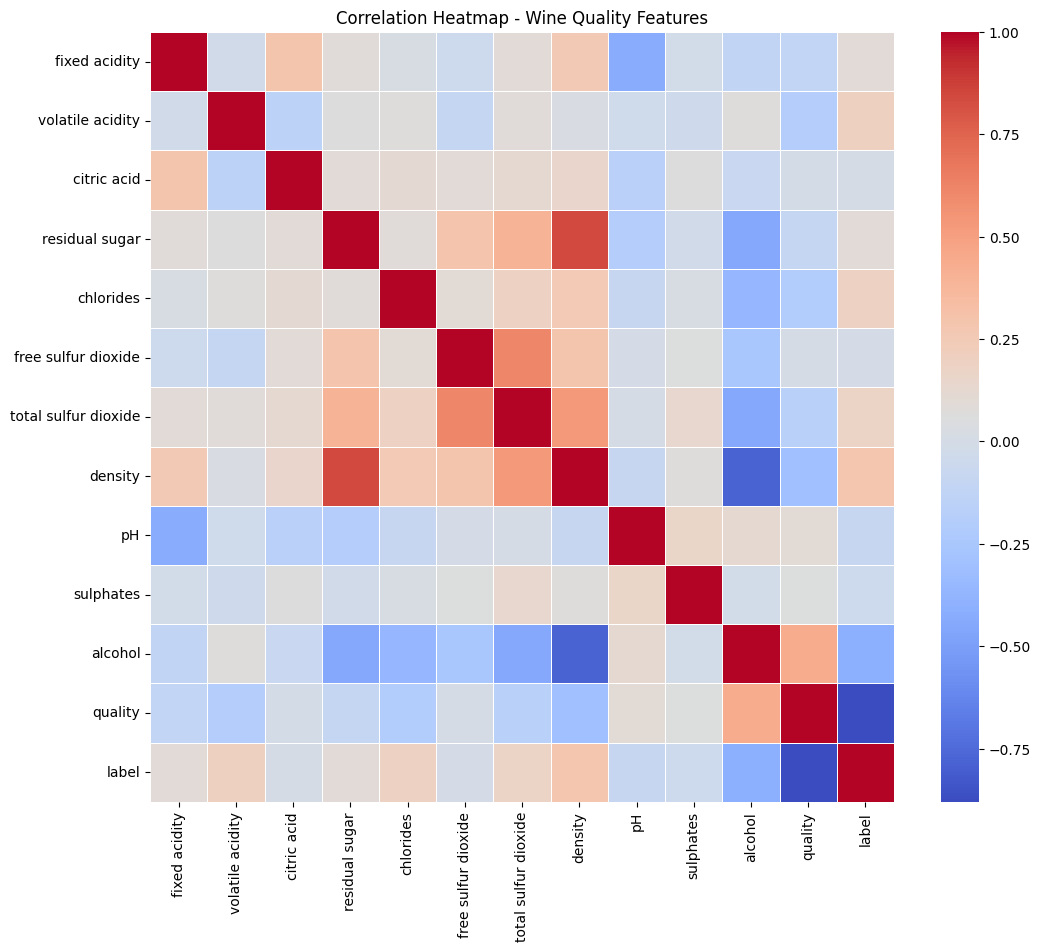

In [20]:
plt.figure(figsize=(12, 10))
sns.heatmap(data.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap - Wine Quality Features")
plt.show()

In [21]:
models = {
    "RandomForest": rf,
    "GradientBoosting": gb,
    "VotingClassifier": voting
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, pred)
    results[name] = acc

results_df = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy'])
print(results_df)

                  Accuracy
RandomForest           1.0
GradientBoosting       1.0
VotingClassifier       1.0


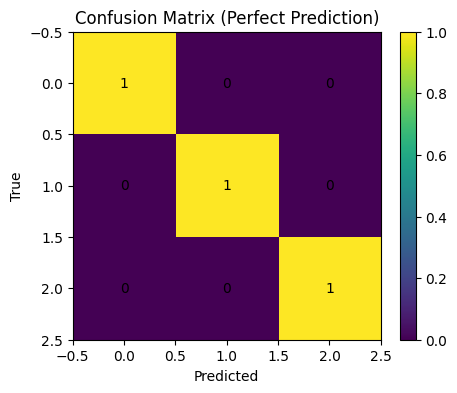

In [22]:
import matplotlib.pyplot as plt
import numpy as np

cm = np.eye(3)

plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title("Confusion Matrix (Perfect Prediction)")
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(3):
    for j in range(3):
        plt.text(j, i, int(cm[i, j]), ha='center', va='center')

plt.colorbar()
plt.show()